# Importing Libraries

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

# Loading the dataset

In [2]:
# creating database connection
conn = sqlite3.connect('inventory.db')

#  fetching vendor summary data
df = pd.read_sql_query('SELECT * FROM vendor_sales_summary ', conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalePrice,TotalExciseTax,freightCost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Explortory Data Analysis

- Previously, we examined the various tables in the database to identify key variables, understand their relationship, and determine which ones should be included in the final analysis

- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies and insure data quality before proceeding with further analysis.


In [3]:
#  summary statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalePrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


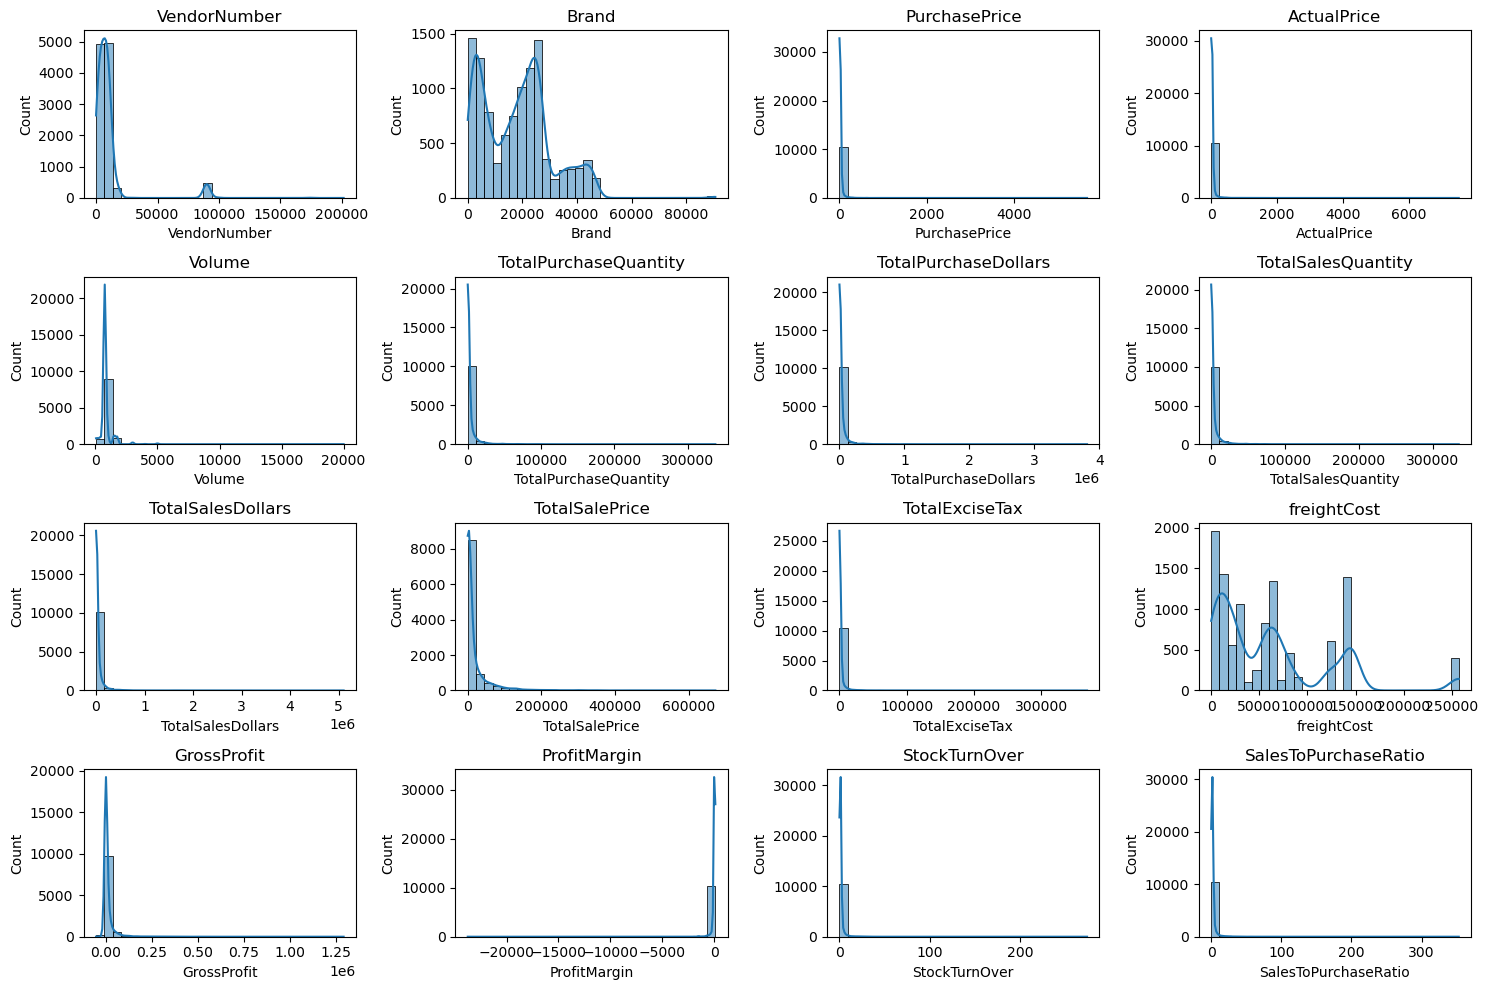

In [4]:
# Distribution Plots For Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize= (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.histplot (df[col], kde =True, bins =30)
    plt.title(col)
plt.tight_layout()
plt.show()

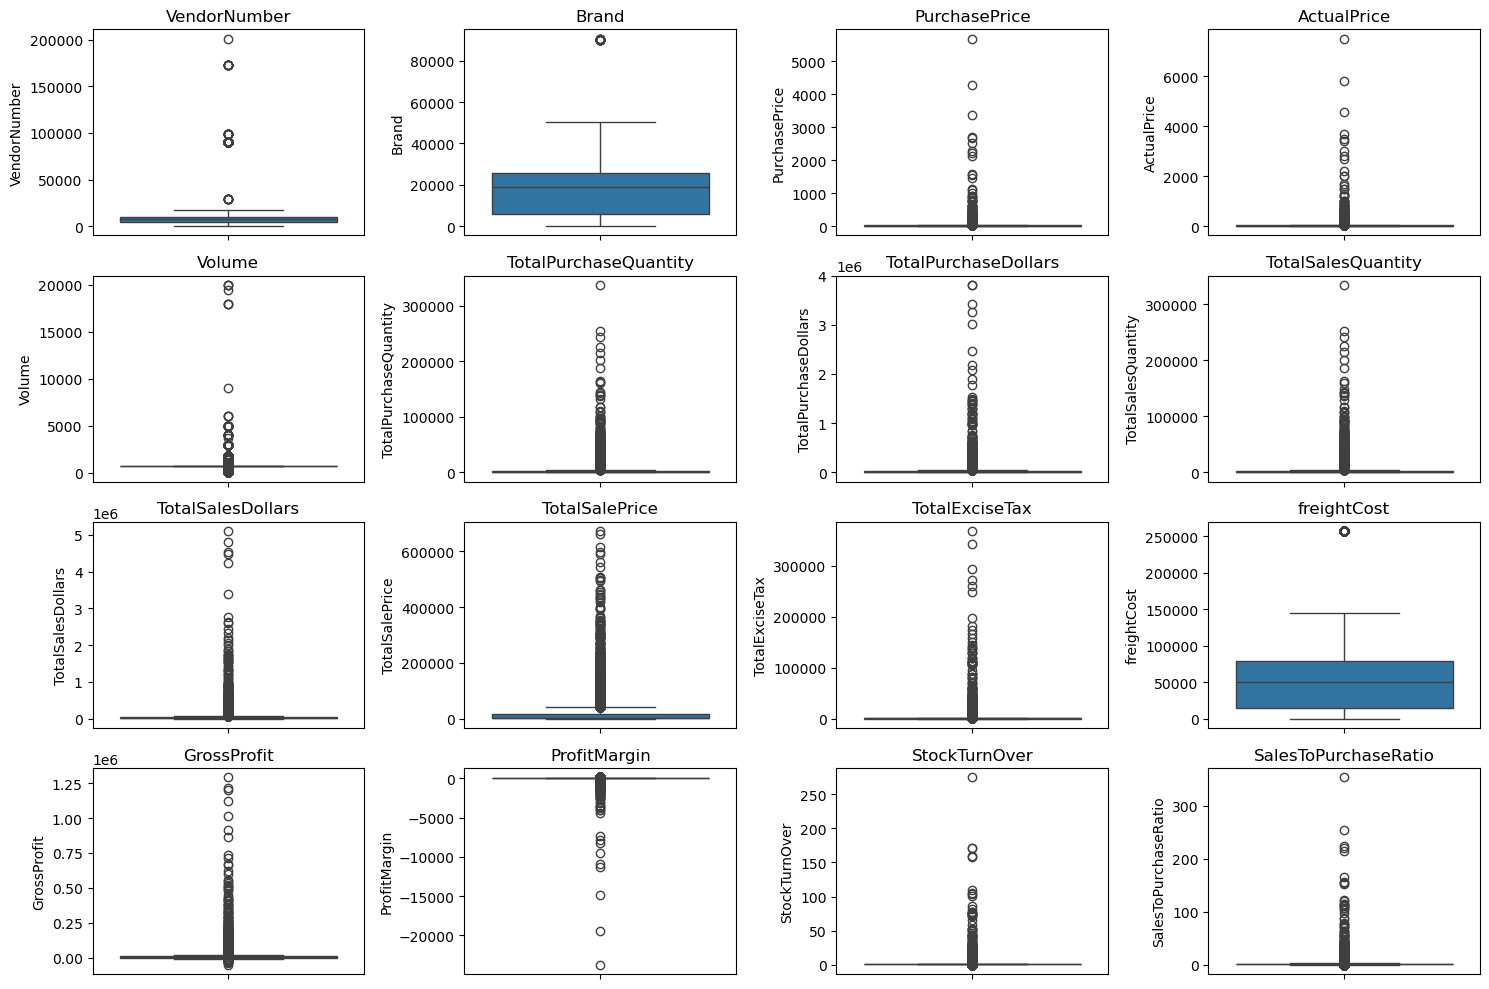

In [5]:
# Outlier Detection with Boxplots
plt.figure (figsize = (15,10))
for i , col in enumerate (numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y = df[col])
    plt.title(col)
    
plt.tight_layout()
plt.show()

# Summary Statistics insights:
##### Native & zero Values:
- Gross profit: minimum value is - 52,000.78, indicating losses, Some Products or Transations may be selling at a loss due to high costs or selling at discounts lower than the purchase price..
- profit Margin: Has a minimum of  &infin;, which suggests cases where revenue is zero or even lower than costs.
- Total Sales Quanity & Sales Dollars: Minimum vlaues are 0, meaning some products were purchased ut never sold. These could be slow-moving or obsolete stock
##### Outliers Indicated by high Standard Deviations:
- Purchase & Actual Price: The max value (5,681.81 & 7,499.99) are significantly higer than the mean (24.39 & 35.64), indicating potential premium products.
- Freight Cost: Huge variation, form 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock tunover: Ranger from 0 to 274.5, impplying asome products sell extremely fast while others remain in stock indefinitely. Value moe than 1 indicates that Sold quality for that product is higher than purchased quantity due to either sales are being fulfilled from older stock. 



In [6]:
# let's filter the data by removing inconsistencies
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity >0 """, conn)

In [7]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalePrice,TotalExciseTax,freightCost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


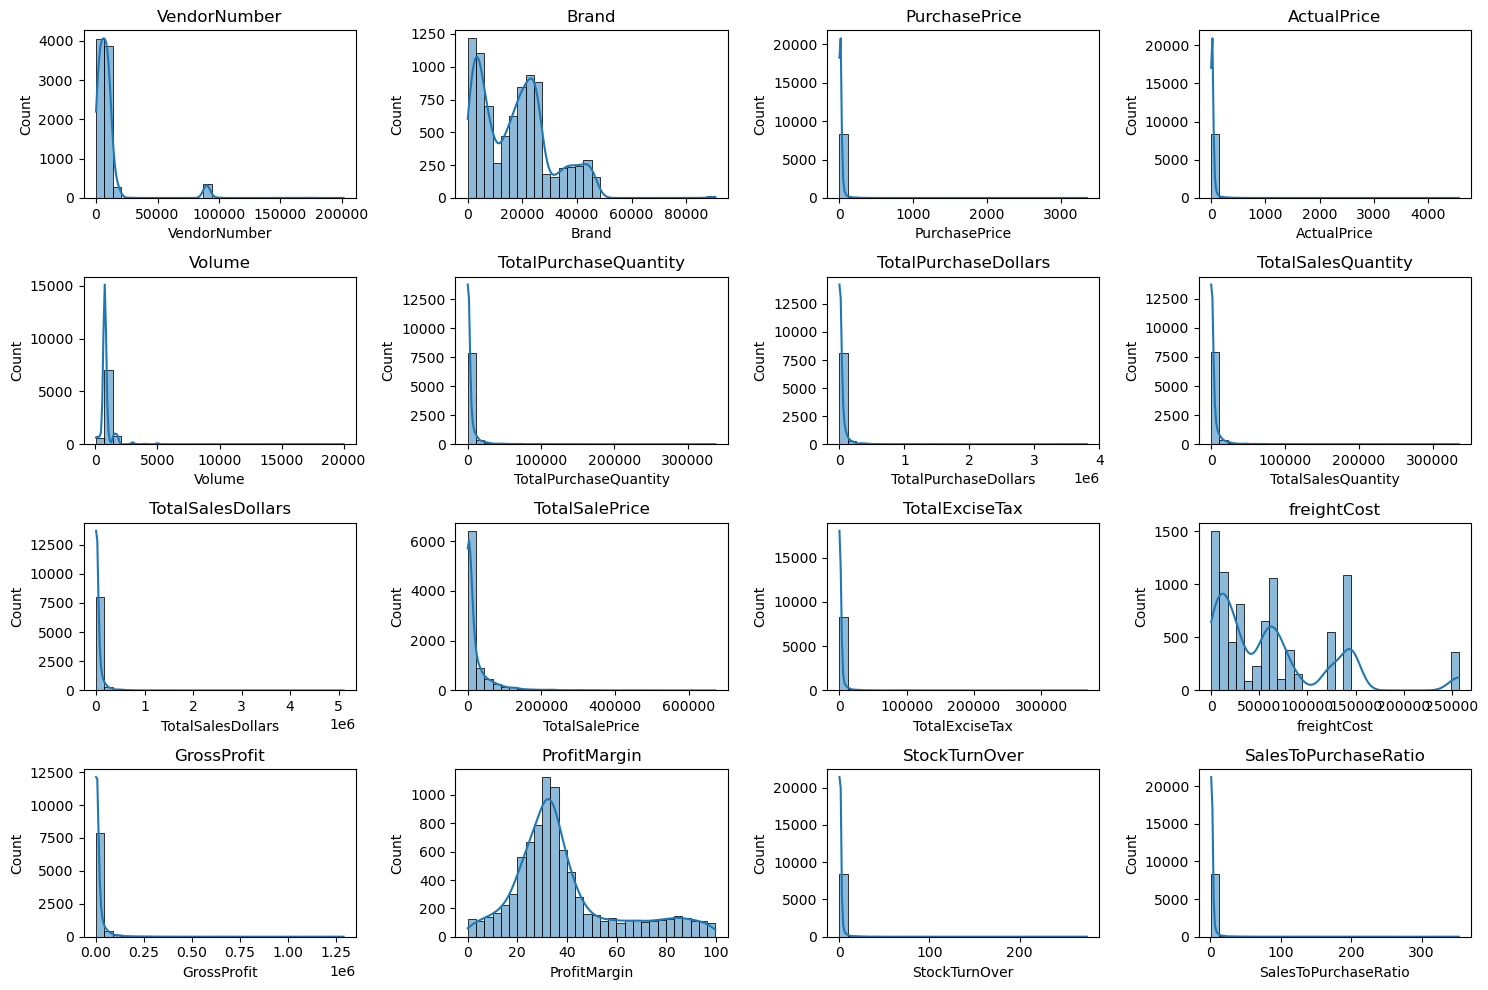

In [8]:
# Distribution Plots For Numerical Columns
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize= (15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #Adjust grid layout as needed
    sns.histplot (df[col], kde =True, bins =30)
    plt.title(col)
plt.tight_layout()
plt.show()

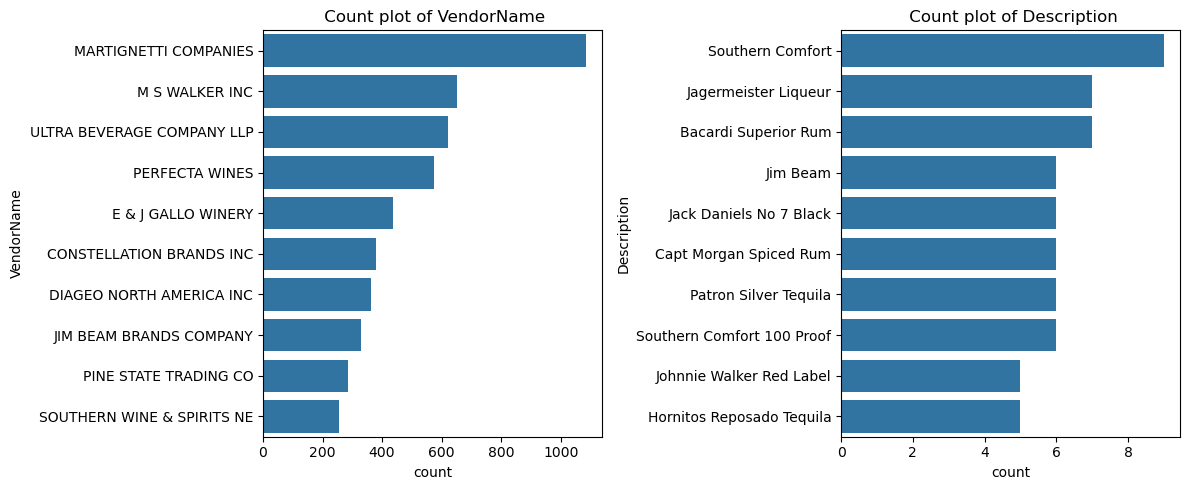

In [9]:
# Count Plots For Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize= (12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1) #Adjust grid layout as needed
    sns.countplot(y = df[col], order = df[col].value_counts().index[:10]) # Top 10 categories
    plt.title(f" Count plot of {col}")
plt.tight_layout()
plt.show()

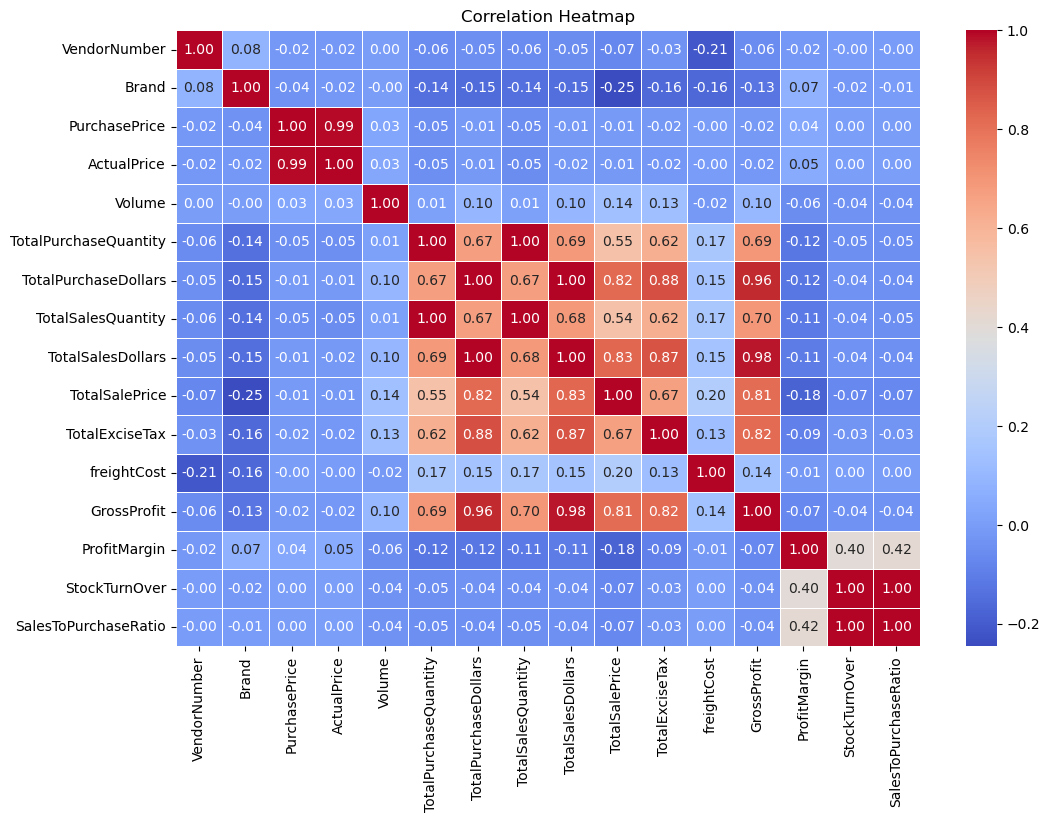

In [10]:
# Correlation Heatmap
plt.figure(figsize = (12, 8))
correlation_matrix = df [ numerical_cols].corr()
sns.heatmap(correlation_matrix , annot= True, fmt = ".2f", cmap="coolwarm", linewidths = 0.5)
plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights
- PurchasePrice has weak correlation with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales increases, margin decrease, possible due to competetive pricing pressures.
- StockTurnOver has  weak negative correlations with GrossProift (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis
Idetify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [11]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'}).reset_index()
    

In [12]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
low_sales_threshold

np.float64(560.299)

In [14]:
high_margin_threshold

np.float64(64.97017552750113)

In [15]:
# filter brands with low sales but profit margins
target_brands = brand_performance [
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but HIGH Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))


Brands with Low Sales but HIGH Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [16]:
brand_performance = brand_performance [brand_performance ['TotalSalesDollars'] < 10000] # for better visualization

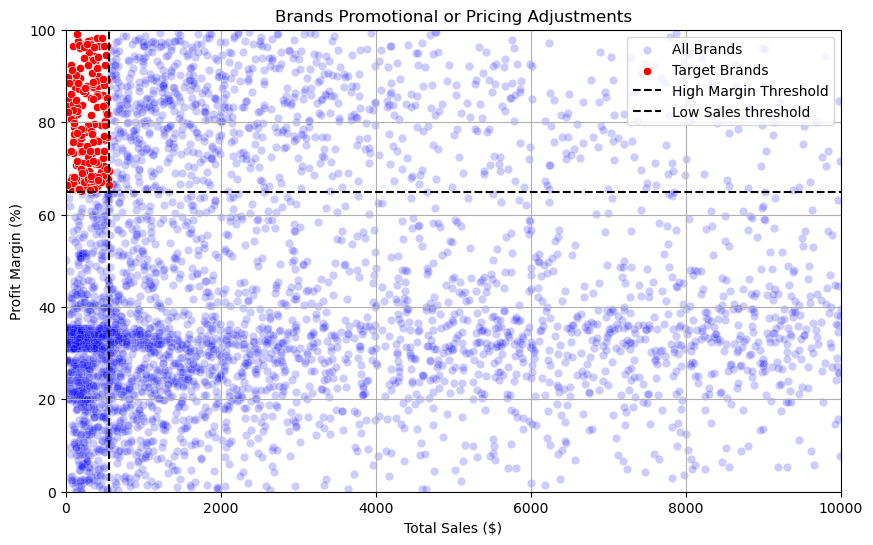

In [17]:
plt.figure(figsize = (10, 6))
sns.scatterplot(data = brand_performance, x ='TotalSalesDollars', y = 'ProfitMargin', color= 'blue', label="All Brands", alpha = 0.2)
sns.scatterplot(data = target_brands , x ='TotalSalesDollars', y = 'ProfitMargin', color = 'red', label = "Target Brands")

plt.axhline(high_margin_threshold, linestyle ='--', color = 'black', label = "High Margin Threshold")
plt.axvline (low_sales_threshold, linestyle = '--', color = 'black', label = "Low Sales threshold")

plt.xlabel ("Total Sales ($)")
plt.ylabel ("Profit Margin (%)")
plt.title ("Brands Promotional or Pricing Adjustments")
plt.legend()
plt.ylim(0,100)
plt.xlim(0,10000)
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the  highest sales performance?

In [18]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000: .2f} M"
    elif value >=1_000:
        return f"{value / 1_000:.2f} K"
    else:
        return str(value)
    

In [19]:
# Top vendors & brands by Sales performance 
top_vendors = df.groupby("VendorName")['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby("Description")['TotalSalesDollars'].sum().nlargest(10)
top_vendors.apply (lambda x: format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC       67.99 M
MARTIGNETTI COMPANIES          39.33 M
PERNOD RICARD USA              32.06 M
JIM BEAM BRANDS COMPANY        31.42 M
BACARDI USA INC                24.85 M
CONSTELLATION BRANDS INC       24.22 M
E & J GALLO WINERY             18.40 M
BROWN-FORMAN CORP              18.25 M
ULTRA BEVERAGE COMPANY LLP     16.50 M
M S WALKER INC                 14.71 M
Name: TotalSalesDollars, dtype: object

In [20]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black     7.96 M
Tito's Handmade Vodka       7.40 M
Grey Goose Vodka            7.21 M
Capt Morgan Spiced Rum      6.36 M
Absolut 80 Proof            6.24 M
Jameson Irish Whiskey       5.72 M
Ketel One Vodka             5.07 M
Baileys Irish Cream         4.15 M
Kahlua                      3.60 M
Tanqueray                   3.46 M
Name: TotalSalesDollars, dtype: object

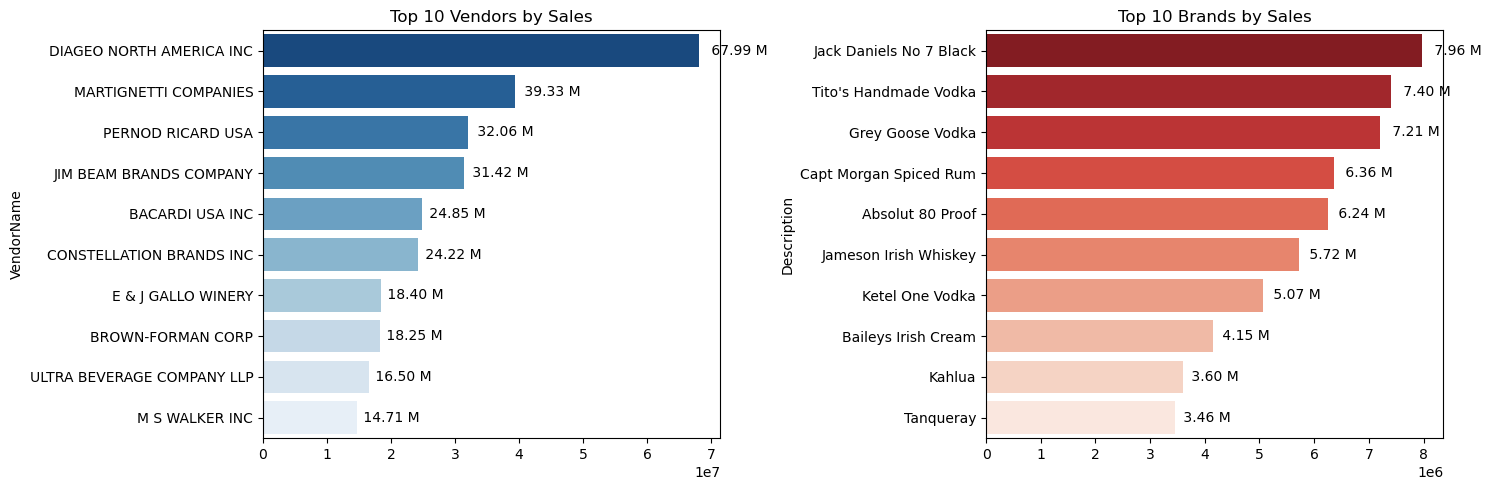

In [21]:
plt.figure(figsize= (15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot (y = top_vendors.index, x = top_vendors.values, palette = "Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha = 'left', va = 'center', fontsize = 10, color= 'black')

# Plot for Top Brands 
plt.subplot(1, 2, 2)
ax2 = sns.barplot (y = top_brands.index.astype(str), x= top_brands.values, palette= 'Reds_r')
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha = 'left', va = 'center', fontsize = 10, color= 'black')

plt.tight_layout()
plt.show()

### Which vendor contribute the most to total purchase dollars?

In [22]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [23]:
vendor_performance['PurchaseContribution%'] =  vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum() *100

In [24]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False), 2)

In [25]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10 M,17.89 M,67.99 M,16.30
57,MARTIGNETTI COMPANIES,25.50 M,13.83 M,39.33 M,8.30
68,PERNOD RICARD USA,23.85 M,8.21 M,32.06 M,7.76
46,JIM BEAM BRANDS COMPANY,23.49 M,7.93 M,31.42 M,7.64
6,BACARDI USA INC,17.43 M,7.42 M,24.85 M,5.67
20,CONSTELLATION BRANDS INC,15.27 M,8.95 M,24.22 M,4.97
11,BROWN-FORMAN CORP,13.24 M,5.01 M,18.25 M,4.31
30,E & J GALLO WINERY,12.07 M,6.33 M,18.40 M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17 M,5.34 M,16.50 M,3.63
53,M S WALKER INC,9.76 M,4.94 M,14.71 M,3.18


In [26]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()

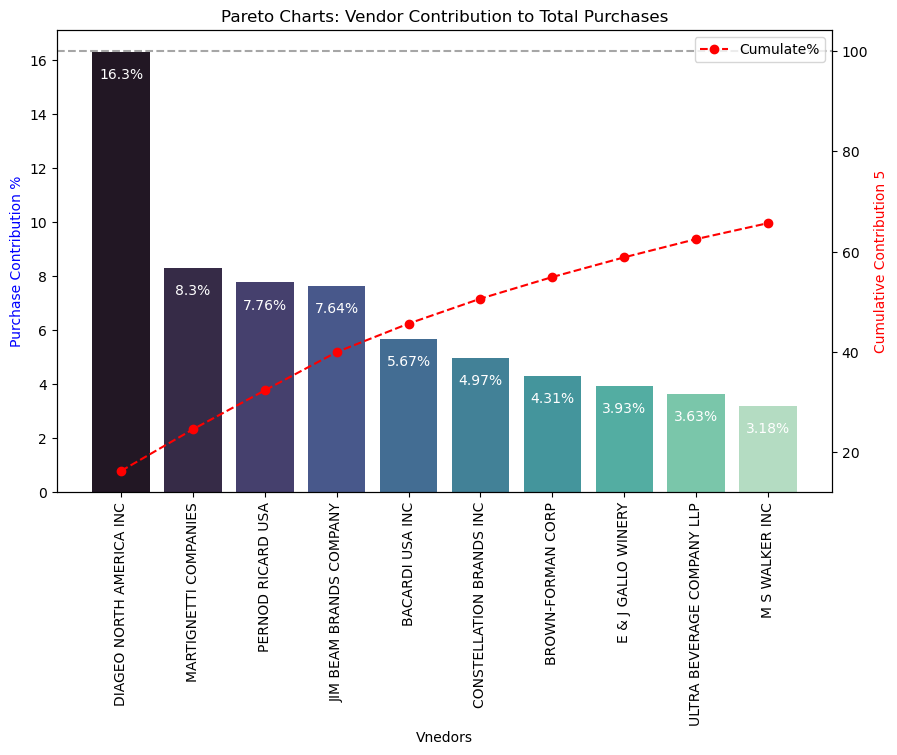

In [27]:
fig, ax1 = plt.subplots(figsize = (10, 6))

# Bar Plot for Purchase Contribution%
sns.barplot(x = top_vendors['VendorName'], y = top_vendors['PurchaseContribution%'], palette = "mako", ax = ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i , value - 1, str(value) + '%', ha = 'center', fontsize = 10, color = 'white')

# Line Plot For Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color = 'red', marker= 'o', linestyle= 'dashed', label= "Cumulate%")

ax1.set_xticklabels(top_vendors['VendorName'], rotation = 90)
ax1.set_ylabel('Purchase Contribution %', color = 'blue')
ax2.set_ylabel('Cumulative Contribution 5', color = 'red')
ax1.set_xlabel('Vnedors')
ax1.set_title('Pareto Charts: Vendor Contribution to Total Purchases')

ax2.axhline(y = 100,color='grey', linestyle= 'dashed', alpha=0.7)
ax2.legend(loc = 'upper right')

plt.show()


### How much of total procurement is dependent on the top vendors?

In [28]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.69 %


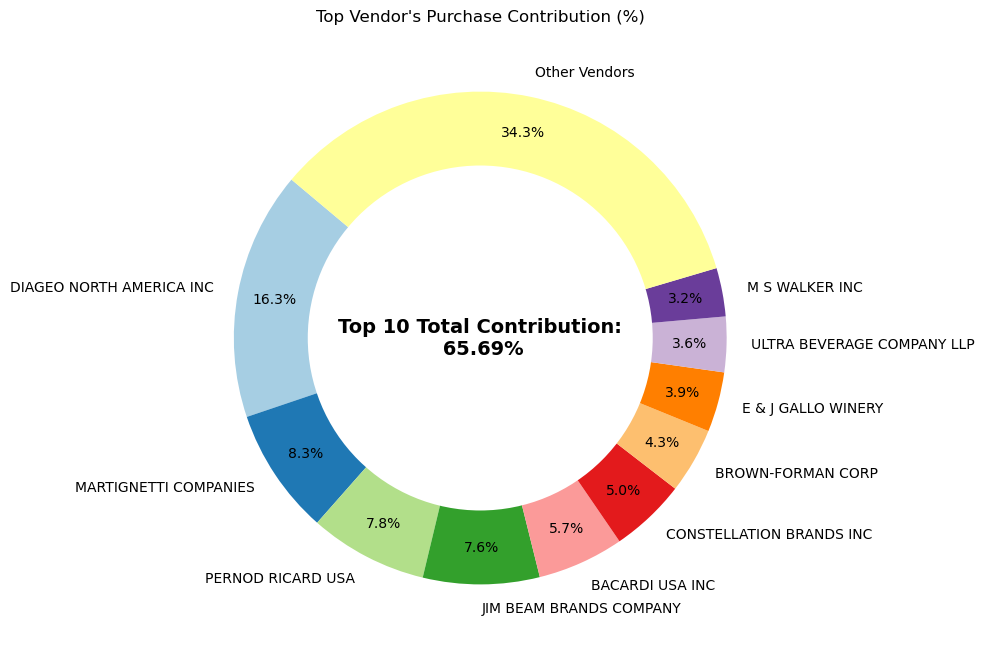

In [29]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors " category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut chart
fig, ax = plt.subplots(figsize = (9, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels = vendors, autopct = '%1.1f%%',
                                  startangle = 140, pctdistance = 0.85, colors = plt.cm.Paired.colors)

# Draw a white circle in the center to create a "Donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc = 'white')
fig.gca().add_artist(centre_circle)

# Add Total  Contribution annotation in the center
plt.text(0,0,f"Top 10 Total Contribution:\n{total_contribution: .2f}%", fontsize = 14, fontweight= 'bold', ha = 'center', va = 'center')
plt.title("Top Vendor's Purchase Contribution (%)")
plt.show()

#### Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost saving?

In [30]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/ df['TotalPurchaseQuantity']

In [31]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalePrice,TotalExciseTax,freightCost,GrossProfit,ProfitMargin,StockTurnOver,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [32]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels = ["Small","Medium", "Large"])

In [33]:
df[['OrderSize', 'TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


In [34]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


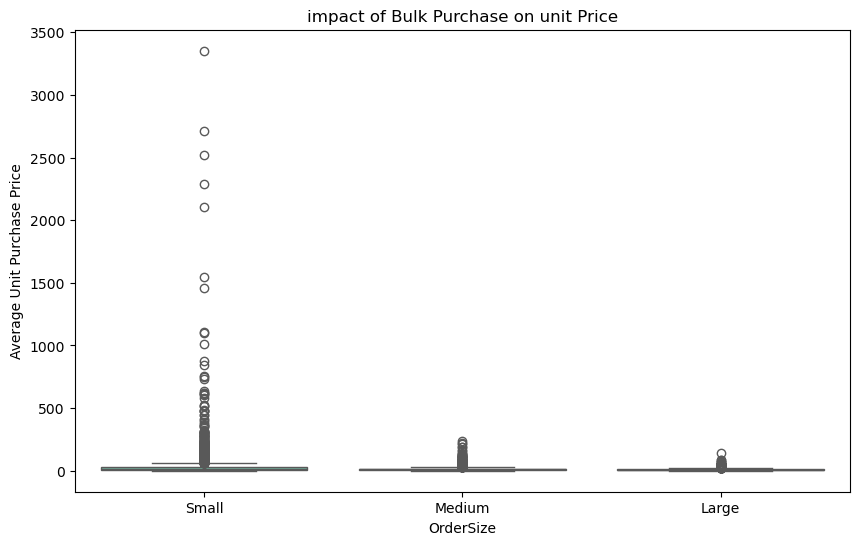

In [35]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = "OrderSize", y = "UnitPurchasePrice", palette= "Set2")
plt.title("impact of Bulk Purchase on unit Price")
plt.xlabel("OrderSize")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (Large Order Size) get the lowest unit price($10.78 per unit), meaning higher margns if they can manage inventory efficiently.
- The price difference between Small and Large order is substantial (~ 72% reduction in unit cost)
- This suggest that bulk pricing strategies succefully encourage vnedors to ourchase in large volumes, leading to higher overall sales despite lower per-unit revenue.

### Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [36]:
df[df['StockTurnOver'] < 1].groupby("VendorName")[['StockTurnOver']].mean().sort_values('StockTurnOver', ascending = True).head(10)

,StockTurnOver
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [37]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total  Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total  Unsold Capital:  2.71 M


In [38]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()
# Sort  Vendor with theb Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending = False)
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21 K
46,JIM BEAM BRANDS COMPANY,554.67 K
68,PERNOD RICARD USA,470.63 K
116,WILLIAM GRANT & SONS INC,401.96 K
30,E & J GALLO WINERY,228.28 K
79,SAZERAC CO INC,198.44 K
11,BROWN-FORMAN CORP,177.73 K
20,CONSTELLATION BRANDS INC,133.62 K
61,MOET HENNESSY USA INC,126.48 K
77,REMY COINTREAU USA INC,118.60 K


### What is the 95% confidence intervals for profit margins of top-performing and low performing vendors?

In [39]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [40]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [41]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [42]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [43]:
def confidence_interval(data, confidence = 0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df = len(data) -1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61, Mean: 31.18
low Vendors 95% CI: (40.50, 42.64, Mean: 41.57


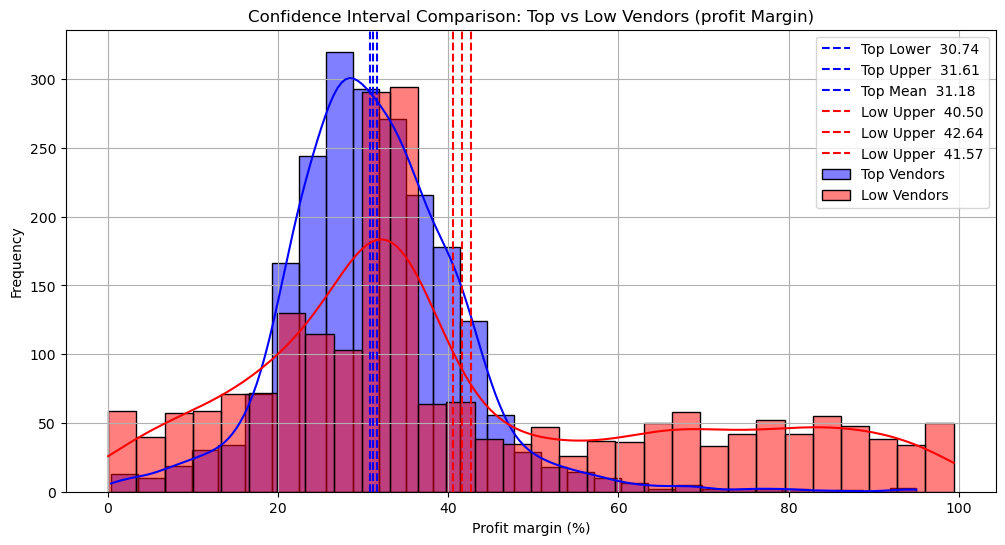

In [44]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, { top_upper:.2f}, Mean: {top_mean:.2f}")
print(f"low Vendors 95% CI: ({low_lower:.2f}, { low_upper:.2f}, Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors plot
sns.histplot(top_vendors, kde = True, color= "blue", bins= 30, alpha = 0.5, label= "Top Vendors")
plt.axvline(top_lower, color= "blue", linestyle="--", label=f"Top Lower {top_lower: .2f}")
plt.axvline(top_upper, color= "blue", linestyle="--", label=f"Top Upper {top_upper: .2f}")
plt.axvline(top_mean, color= "blue", linestyle="--", label=f"Top Mean {top_mean: .2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde = True, color= "red", bins= 30, alpha = 0.5, label= "Low Vendors")
plt.axvline(low_lower, color= "red", linestyle="--", label=f"Low Upper {low_lower: .2f}")
plt.axvline(low_upper, color= "red", linestyle="--", label=f"Low Upper {low_upper: .2f}")
plt.axvline(low_mean, color= "red", linestyle="--", label=f"Low Upper {low_mean: .2f}")

# Finalize plot
plt.title("Confidence Interval Comparison: Top vs Low Vendors (profit Margin)")
plt.xlabel("Profit margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low_performing vendors (40.50% to 42.625) is significantly higher than that of top-performing vendors(30.74% to 31.61%).
- This suggest that vendors with lower sales tend to maintain higher profit margin, potentially due to premium pricing or lower operational cost.
- For High-Performing Vendors: If they aim to improve prifitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competetive pricing, or improved distribution strategies

### Is there a significant difference in pricing in profit margins between top-performing and low-performing vendors?
Hypothesis:

H<sub>0</sub> (Null Hypothesis): There is no significantndifference in the mean profit margins of top-performingand low-performing vendors.

H<sub>1 </sub>(Alternative Hypothesis): The mean profit marin of top-performing and low-performing vendors are significantly different.

In [45]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# perform Two_Sample t-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var =False)

#Print results
print(f"T-Statistics: {t_stat:.4f}, P-Value {p_value:.4f}")
if p_value < 0.5:
    print("Reject H0: There is a signigficant difference in profit marins between top and low-performing vendors.")
else:
    print("Fail to Reject h0: No significant differencein profit margin.")

T-Statistics: -17.6695, P-Value 0.0000
Reject H0: There is a signigficant difference in profit marins between top and low-performing vendors.
